# Notebook 9 - Topic 13 Clustering

This notebook is the unsupervised learning pass. The supervised notebooks already knew the emotion labels during training. Clustering does not get that luxury: K-Means only sees the feature vectors and tries to find groups based on distance.

The labels still matter for evaluation after the fact. ARI, NMI, and cluster composition are basically asking: did the unsupervised groups accidentally line up with the real emotion labels, or did they find some other structure in the audio features?

In [1]:
from pathlib import Path
import sys
import warnings

ROOT = Path.cwd()
if not (ROOT / "features" / "features.csv").exists():
    maybe_root = ROOT.parent
    if (maybe_root / "features" / "features.csv").exists():
        ROOT = maybe_root
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans as SkKMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import StandardScaler as SkStandardScaler

from minilearn.clustering import KMeans
from minilearn.preprocessing import PCA, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 432
FEATURE_PATH = ROOT / "features" / "features.csv"

## Load features

Same feature table, different task. The emotion labels are kept out of clustering and only used afterward for scoring/plots.

Scaling matters a lot here because K-Means is distance-based. If one feature has a huge numeric range, it can dominate the Euclidean distance even if it is not conceptually more important.

In [2]:
META_COLS = {
    "filename",
    "emotion",
    "emotion_id",
    "actor",
    "gender",
    "vocalchannel",
    "intensity",
    "statement",
    "repetition",
    "duration",
}

df = pd.read_csv(FEATURE_PATH)
feature_cols = [c for c in df.columns if c not in META_COLS]
X = df[feature_cols].to_numpy(dtype=float)
y = df["emotion_id"].to_numpy()

emotion_names = (
    df[["emotion_id", "emotion"]]
    .drop_duplicates()
    .sort_values("emotion_id")
    .set_index("emotion_id")["emotion"]
    .to_dict()
)
labels = sorted(emotion_names)
target_names = [emotion_names[i] for i in labels]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"rows={len(df)}, features={len(feature_cols)}, true_emotions={len(labels)}")
print(emotion_names)

rows=2452, features=407, true_emotions=8
{1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}


## MiniLearn K-Means at k = 8

There are 8 real emotion classes, so the first clustering run uses 8 clusters. This is not giving K-Means the labels. It only tells K-Means how many groups to make.

The important expectation check: unsupervised clusters usually will not match emotion labels perfectly. The audio features might group by speaker, intensity, song vs speech, or broad acoustic energy instead of clean emotion categories.

In [3]:
mini_kmeans = KMeans(n_clusters=8, max_iter=100, n_init=6, random_state=RANDOM_STATE)
mini_clusters = mini_kmeans.fit_predict(X_scaled)

sk_kmeans = SkKMeans(n_clusters=8, n_init=10, random_state=RANDOM_STATE)
sk_clusters = sk_kmeans.fit_predict(X_scaled)

cluster_scores = pd.DataFrame([
    {
        "model": "MiniLearn KMeans",
        "k": 8,
        "inertia": mini_kmeans.inertia_,
        "ARI": adjusted_rand_score(y, mini_clusters),
        "NMI": normalized_mutual_info_score(y, mini_clusters),
        "silhouette": silhouette_score(X_scaled, mini_clusters),
    },
    {
        "model": "sklearn KMeans",
        "k": 8,
        "inertia": sk_kmeans.inertia_,
        "ARI": adjusted_rand_score(y, sk_clusters),
        "NMI": normalized_mutual_info_score(y, sk_clusters),
        "silhouette": silhouette_score(X_scaled, sk_clusters),
    },
])
cluster_scores.round(4)

,model,k,inertia,ARI,NMI,silhouette
0,MiniLearn KMeans,8,573478.6374,0.0806,0.1632,0.097
1,sklearn KMeans,8,571641.7679,0.0839,0.1716,0.098


## Cluster composition

A cluster composition table is more useful than just staring at ARI/NMI. Each row is one cluster. The values show what fraction of that cluster came from each true emotion.

If clustering were perfectly aligned with emotion, each row would be almost all one color. If the rows are mixed, the unsupervised structure is not the same as the supervised labels.

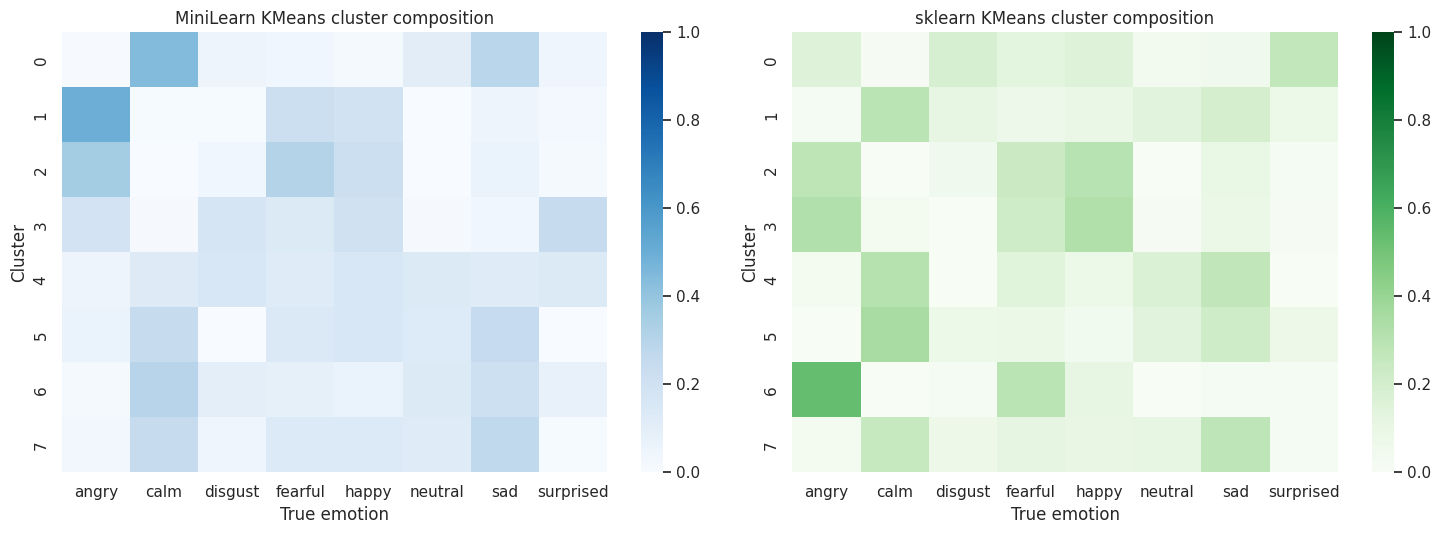

emotion,angry,calm,disgust,fearful,happy,neutral,sad,surprised
cluster,,,,,,,,
0,0.01,0.44,0.05,0.04,0.02,0.11,0.29,0.04
1,0.50,0.01,0.01,0.22,0.19,0.00,0.05,0.02
2,0.36,0.00,0.04,0.31,0.22,0.00,0.07,0.02
3,0.18,0.01,0.17,0.14,0.20,0.01,0.04,0.25
4,0.05,0.13,0.16,0.12,0.16,0.14,0.12,0.13
5,0.07,0.25,0.00,0.14,0.16,0.13,0.25,0.00
6,0.02,0.30,0.10,0.09,0.07,0.14,0.21,0.08
7,0.03,0.25,0.05,0.14,0.14,0.12,0.27,0.01


In [4]:
def composition_table(cluster_labels):
    tmp = pd.DataFrame({"cluster": cluster_labels, "emotion": [emotion_names[i] for i in y]})
    counts = pd.crosstab(tmp["cluster"], tmp["emotion"])
    return counts.div(counts.sum(axis=1), axis=0)

mini_comp = composition_table(mini_clusters)
sk_comp = composition_table(sk_clusters)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(mini_comp, cmap="Blues", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("MiniLearn KMeans cluster composition")
axes[0].set_xlabel("True emotion")
axes[0].set_ylabel("Cluster")
sns.heatmap(sk_comp, cmap="Greens", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("sklearn KMeans cluster composition")
axes[1].set_xlabel("True emotion")
axes[1].set_ylabel("Cluster")
plt.tight_layout()
plt.show()

mini_comp.round(2)

## K sweep: elbow, silhouette, ARI, NMI

The true class count is 8, but K-Means does not know what an emotion is. Sweeping `k` shows whether 8 clusters is actually natural for this feature space.

- Inertia always tends to drop as k increases, so it is mostly for elbow shape.
- Silhouette looks at separation/compactness without using emotion labels.
- ARI and NMI use emotion labels after clustering, so they tell us label alignment.

In [5]:
sweep_rows = []
for k in range(2, 13):
    model = SkKMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    clusters = model.fit_predict(X_scaled)
    sweep_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, clusters),
        "ARI": adjusted_rand_score(y, clusters),
        "NMI": normalized_mutual_info_score(y, clusters),
    })

sweep = pd.DataFrame(sweep_rows)
sweep.round(4)

,k,inertia,silhouette,ARI,NMI
0,2,783992.2440,0.1783,0.0679,0.0953
1,3,715353.4158,0.1537,0.0786,0.1242
2,4,658977.8231,0.1277,0.0734,0.1355
3,5,624528.8914,0.1237,0.0996,0.1678
4,6,603420.0602,0.1096,0.0915,0.1658
5,7,586112.4971,0.1032,0.0852,0.1642
6,8,571641.7679,0.0980,0.0839,0.1716
7,9,558090.2666,0.0933,0.0823,0.1692
8,10,546750.7432,0.0949,0.0827,0.1749
9,11,536899.7169,0.0937,0.0779,0.1751


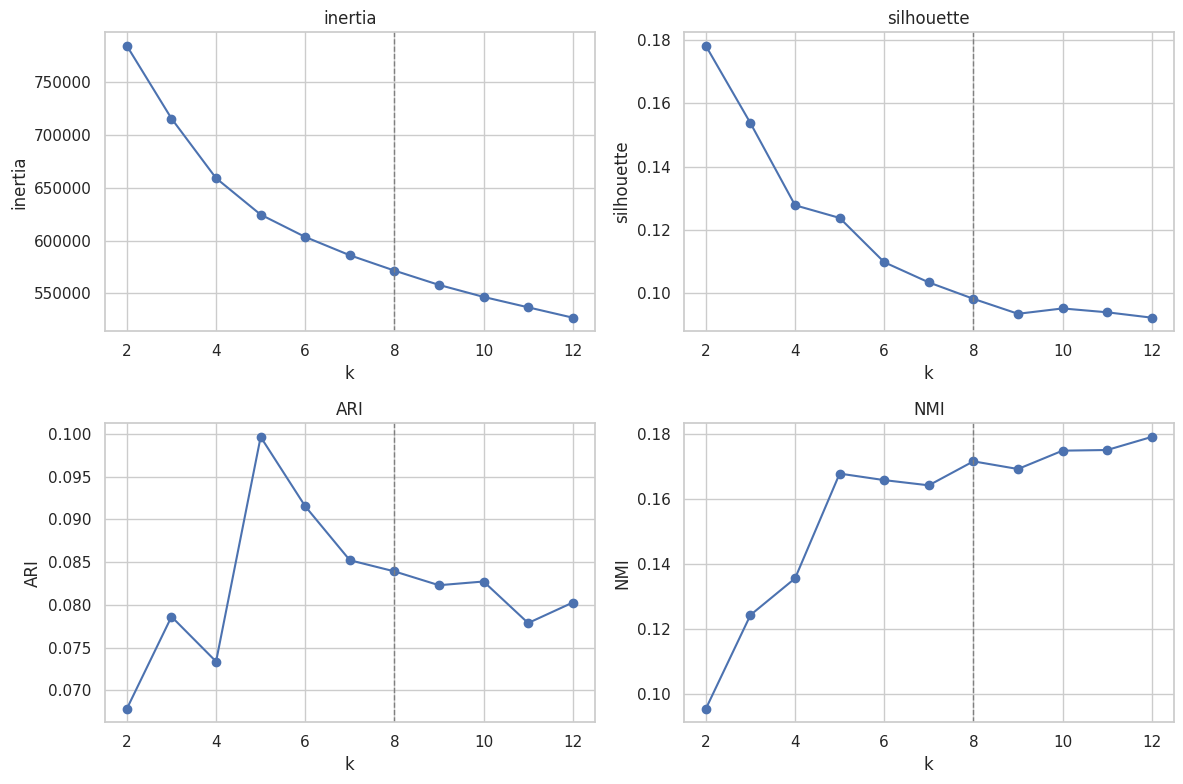

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ["inertia", "silhouette", "ARI", "NMI"]
for ax, metric in zip(axes.ravel(), metrics):
    ax.plot(sweep["k"], sweep[metric], marker="o")
    ax.axvline(8, color="gray", linestyle="--", linewidth=1)
    ax.set_title(metric)
    ax.set_xlabel("k")
    ax.set_ylabel(metric)
plt.tight_layout()
plt.show()

## PCA projection

PCA gives a quick 2D view of the scaled feature table. It is linear, so it will not magically untangle everything, but it is fast and easy to explain.

The first plot uses true emotion labels. The second plot uses K-Means clusters. If those two plots tell different stories, that is the main unsupervised-learning lesson.

PCA explained variance ratio: [0.3288, 0.1276]


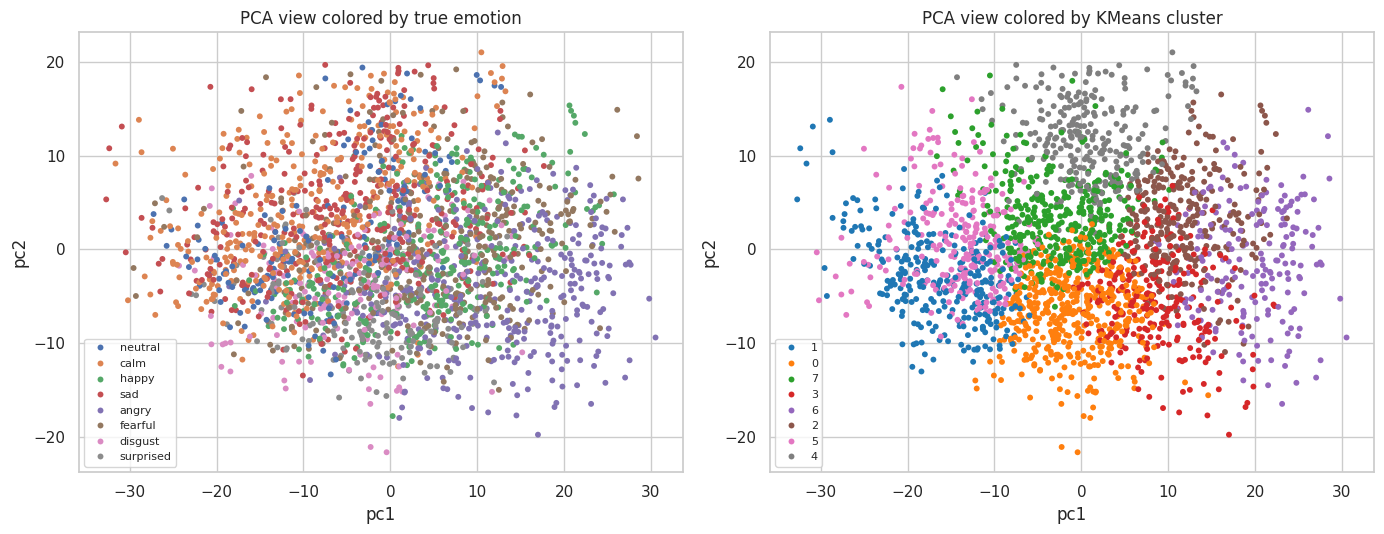

In [7]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
pca_df = pd.DataFrame({
    "pc1": X_pca2[:, 0],
    "pc2": X_pca2[:, 1],
    "emotion": [emotion_names[i] for i in y],
    "cluster": sk_clusters.astype(str),
})

print("PCA explained variance ratio:", np.round(pca2.explained_variance_ratio_, 4).tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="emotion", s=18, linewidth=0, ax=axes[0])
axes[0].set_title("PCA view colored by true emotion")
axes[0].legend(loc="best", fontsize=8)
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="cluster", palette="tab10", s=18, linewidth=0, ax=axes[1])
axes[1].set_title("PCA view colored by KMeans cluster")
axes[1].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## t-SNE projection

PCA is linear. t-SNE is nonlinear and often better at showing local neighborhoods. It is also easier to overread, so this plot is evidence for exploration, not a final metric.

To keep runtime sane, t-SNE runs on a 30-component PCA reduction first.

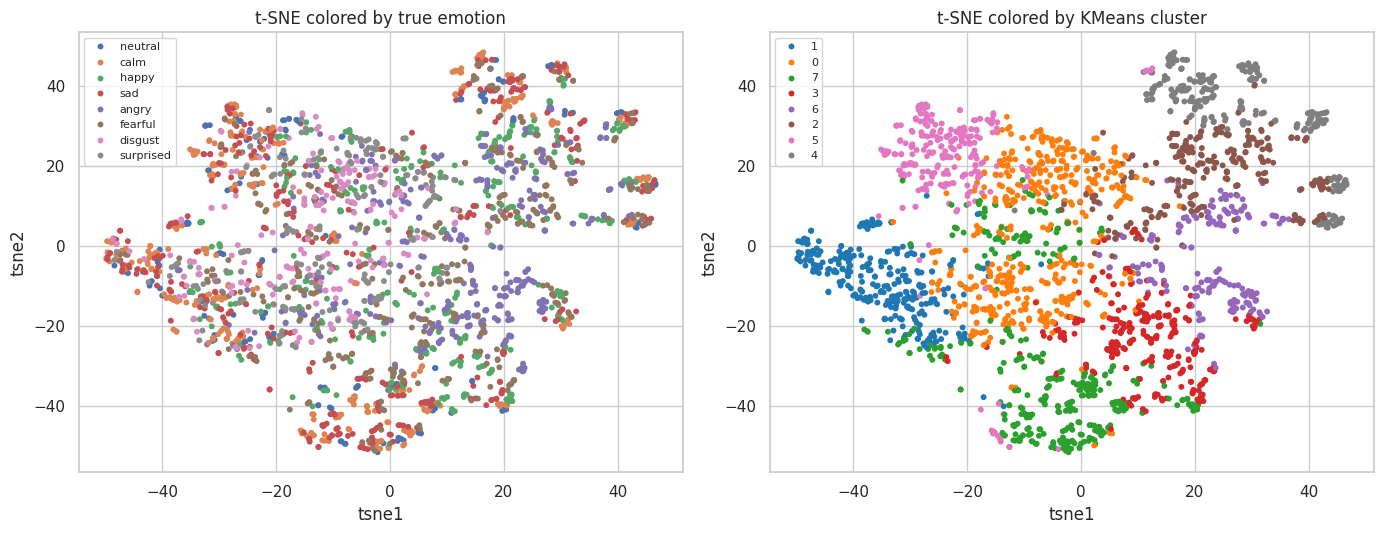

In [8]:
pca30 = PCA(n_components=30)
X_pca30 = pca30.fit_transform(X_scaled)
tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate="auto",
    init="pca",
    max_iter=750,
    random_state=RANDOM_STATE,
)
X_tsne = tsne.fit_transform(X_pca30)
tsne_df = pd.DataFrame({
    "tsne1": X_tsne[:, 0],
    "tsne2": X_tsne[:, 1],
    "emotion": [emotion_names[i] for i in y],
    "cluster": sk_clusters.astype(str),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=tsne_df, x="tsne1", y="tsne2", hue="emotion", s=18, linewidth=0, ax=axes[0])
axes[0].set_title("t-SNE colored by true emotion")
axes[0].legend(loc="best", fontsize=8)
sns.scatterplot(data=tsne_df, x="tsne1", y="tsne2", hue="cluster", palette="tab10", s=18, linewidth=0, ax=axes[1])
axes[1].set_title("t-SNE colored by KMeans cluster")
axes[1].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## What the clustering result means

- K-Means uses distance to form compact groups. It does not know anything about emotion labels.
- ARI and NMI being modest is not a failure of the code. It means the acoustic feature space does not naturally break into the exact emotion categories using simple spherical clusters.
- Scaling is non-negotiable here because distance is the whole model.
- PCA/t-SNE can show local structure, but the final conclusion should come from the metrics plus the composition heatmap.
- For this SER project, clustering is best treated as exploratory analysis. The supervised models are still the right tool when labeled emotion examples are available.